In [ ]:
!pip install optuna

In [ ]:

import networkx as nx
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import optuna
from sklearn.metrics import normalized_mutual_info_score
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans
from keras.layers import Input, Dense
from keras.models import Model
def dat_to_adjacency_matrix(file_path):
    # Read data from the .dat file
    with open(file_path, 'r') as file:
        lines = file.readlines()

    # Initialize an empty dictionary to store edges
    edges = {}

    # Process each line in the file
    for line in lines:
        # Split the line into two nodes
        node1, node2 = map(int, line.strip().split())

        # Add the nodes to the dictionary
        if node1 in edges:
            edges[node1].append(node2)
        else:
            edges[node1] = [node2]

    # Determine the number of nodes in the network
    num_nodes = max(edges.keys())

    # Initialize an empty adjacency matrix
    adj_matrix = [[0] * num_nodes for _ in range(num_nodes)]

    # Fill the adjacency matrix based on the edges
    for node1 in edges:
        for node2 in edges[node1]:
            adj_matrix[node1 - 1][node2 - 1] = 1  # Subtract 1 to adjust for 0-based indexing

    return np.array(adj_matrix)


def read_labels_from_file_dat(file_path):
    """
    Read the labels from a .dat file.
    """
    labels = np.loadtxt(file_path, delimiter='\t', dtype=int)
    return labels[:, 1].astype(int)  # Assuming the labels are in the first column


In [ ]:
file_path = "/content/network.dat"
adj_matrix = dat_to_adjacency_matrix(file_path)
print(adj_matrix)
print(adj_matrix.shape)

ground_truth_file = '/content/community.dat'

# Assuming the function read_labels_from_file_dat reads the ground truth labels from a file
labels = read_labels_from_file_dat(ground_truth_file)
ground=labels
print(ground)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 1 1]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 1 0]
 [0 1 0 ... 1 0 0]
 [0 1 0 ... 0 0 0]]
(128, 128)
[3 2 3 2 1 2 2 3 3 3 4 1 4 1 1 4 1 2 2 2 1 4 2 1 3 2 3 1 3 1 2 1 2 2 4 4 1
 2 2 2 1 4 4 1 4 3 3 1 1 1 4 1 2 3 1 3 4 3 1 1 3 4 3 2 2 4 4 3 4 1 4 2 4 2
 4 4 3 3 3 2 2 1 3 3 1 4 3 3 2 2 4 3 3 4 4 2 3 1 1 1 3 1 3 4 4 2 3 1 4 4 3
 2 4 2 1 1 2 4 3 2 4 4 1 1 4 3 2 2]


In [ ]:
graph = nx.from_numpy_array(adj_matrix)

In [ ]:

import networkx as nx
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import optuna
from sklearn.metrics import normalized_mutual_info_score
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans
from keras.layers import Input, Dense
from keras.models import Model
def read_labels_from_file(file_path):
    """
    Read the labels from a text file.
    """
    with open(file_path, 'r') as file:
        labels = [int(line.strip()) for line in file]
    return labels

def read_gml_to_adjacency_matrix(file_path):
    # Read the GML file into a NetworkX graph
    G = nx.read_gml(file_path, label='id')

    # Convert the graph to an adjacency matrix
    adjacency_matrix = nx.convert_matrix.to_numpy_array(G)

    return adjacency_matrix

In [ ]:

graph = '/content/football.gml'
Labels = '/content/groundTruth.txt'
labels = read_labels_from_file(Labels)
adj_matrix= read_gml_to_adjacency_matrix(graph)
# Number of nodes
num_nodes = adj_matrix.shape[0]
print("Number of nodes:", num_nodes)

# Number of edges
num_edges = int(np.sum(adj_matrix) / 2)  # Divide by 2 since the graph is undirected
print("Number of edges:", num_edges)

# Number of clusters (assuming ground truth labels are available)
num_clusters = len(np.unique(labels))
print("Number of clusters:", num_clusters)
ground = labels
graph = nx.from_numpy_array(adj_matrix)

Number of nodes: 115
Number of edges: 613
Number of clusters: 12


In [ ]:


# Function to create similarity matrices
def create_similarity_matrices(A):
    # Degree matrix
    D = np.diag(A.sum(axis=1))
    D_inv_sqrt = np.diag(1 / np.sqrt(A.sum(axis=1)))

    # Normalized adjacency matrix
    A_normalized = D_inv_sqrt @ A @ D_inv_sqrt
    A_normalized = normalize(A_normalized, norm='l1', axis=1)

    # Jaccard similarity
    intersection = np.dot(A, A)
    row_sums = intersection.sum(axis=1)
    Jaccard = intersection / (row_sums[:, None] + row_sums[None, :] - intersection)
    np.fill_diagonal(Jaccard, 0)  # Ensure diagonal is zero for Jaccard

    # Adamic-Adar index
    aa_index = np.zeros_like(A, dtype=np.float64)
    for i in range(A.shape[0]):
        for j in range(A.shape[0]):
            if i != j and A[i, j] > 0:
                log_sum = np.log(A[i].sum())
                if log_sum != 0:
                    aa_index[i, j] = 1 / log_sum
                else:
                    aa_index[i, j] = 0

    return [A_normalized, Jaccard, aa_index]

# Function to combine similarity matrices
def combine_similarity_matrices(similarity_matrices):
    # Stack matrices along the third axis (feature axis)
    combined_matrix = np.stack(similarity_matrices, axis=-1)
    return combined_matrix



In [ ]:
import numpy as np
import networkx as nx
from sklearn.cluster import KMeans
from sklearn.metrics import normalized_mutual_info_score
from keras.layers import Input, Dense
from keras.models import Model
from sklearn.decomposition import NMF
import matplotlib.pyplot as plt
import random
from collections import defaultdict

# Function to calculate NMI using KMeans clustering
def calculate_nmi(embeddings, labels, n_clusters):
    kmeans = KMeans(n_clusters=n_clusters)
    clusters = kmeans.fit_predict(embeddings)
    nmi = normalized_mutual_info_score(labels, clusters)
    return nmi

# Your method: Autoencoder + KMeans
def autoencoder_embeddings(combined_matrix, encoding_dim, batch_size, epochs):
    num_nodes = combined_matrix.shape[0]
    flattened_matrix = combined_matrix.reshape(num_nodes, -1)
    input_dim = flattened_matrix.shape[1]

    input_layer = Input(shape=(input_dim,))
    encoded = Dense(encoding_dim, activation='relu')(input_layer)
    decoded = Dense(input_dim, activation='sigmoid')(encoded)
    autoencoder = Model(input_layer, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    autoencoder.fit(flattened_matrix, flattened_matrix, epochs=epochs, batch_size=batch_size, verbose=0)

    encoder = Model(input_layer, encoded)
    embeddings = encoder.predict(flattened_matrix)
    return embeddings


In [ ]:
import networkx as nx
import numpy as np

# Definitions

def density_i(G, i):
    ki = G.degree(i)
    density = sum(len(set(G.neighbors(i)).intersection(set(G.neighbors(j)))) / (2 * ki) for j in G.neighbors(i))
    return density

def percentile_25(S):
    return np.percentile(S, 25)

def is_core_node(density_i, percentile_25_density):
    return density_i >= percentile_25_density

def sim_ij(G, i, j):
    ki = G.degree(i)
    kj = G.degree(j)
    nij = len(set(G.neighbors(i)).intersection(set(G.neighbors(j))))
    similarity = nij / (ki + kj)
    return similarity

def sim_i_S(G, i, S):
    ki = G.degree(i)
    similarity = sum(len(set(G.neighbors(i)).intersection(S)) / ki for j in G.neighbors(i) if j in S)
    return similarity

# Algorithm 1

def select_nodes(G, k):
    NodesSet = list(G.nodes)
    density_G = [density_i(G, i) for i in NodesSet]
    percentile_25_density_G = percentile_25(density_G)
    CoreNodes = [i for i, d in zip(NodesSet, density_G) if is_core_node(d, percentile_25_density_G)]

    weights = {(i, j): (1 - sim_ij(G, i, j)) for i in G.nodes() for j in G.nodes() if G.has_edge(i, j)}

    SelectedNodes = []

    # Find the pair of core nodes with the maximum shortest path length
    u, v = max([(i, j) for i in CoreNodes for j in CoreNodes if i != j], key=lambda x: nx.shortest_path_length(G, source=x[0], target=x[1]))

    # Choose nodes u and v based on their degrees
    u_neighbors = list(G.neighbors(u)) + [u]
    v_neighbors = list(G.neighbors(v)) + [v]
    u = max(u_neighbors, key=lambda x: G.degree(x) if x not in SelectedNodes else float('-inf'))
    v = max(v_neighbors, key=lambda x: G.degree(x) if x not in SelectedNodes else float('-inf'))

    SelectedNodes.extend([u, v])

    while len(SelectedNodes) < k:
        u = max([node for node in CoreNodes if node not in SelectedNodes], key=lambda x: min(nx.shortest_path_length(G, source=x, target=j) for j in SelectedNodes))

        u_neighbors = list(G.neighbors(u)) + [u]
        u = max(u_neighbors, key=lambda x: G.degree(x) if x not in SelectedNodes else float('-inf'))
        SelectedNodes.append(u)

    return SelectedNodes[:k]


In [ ]:
def embeddings_to_dict(embedding_matrix, node_ids):
    embeddings_dict = {}
    for i, node_id in enumerate(node_ids):
        embeddings_dict[node_id] = embedding_matrix[i]
    return embeddings_dict


In [ ]:
def extract_subgraph_embedding(graph, subgraph, embedding):
    """
    Extracts embeddings of nodes in a subgraph from the embeddings of the entire graph.

    Parameters:
        graph (networkx.Graph): The entire graph.
        subgraph (networkx.Graph): The subgraph for which embeddings need to be extracted.
        embedding (dict): A dictionary containing node embeddings for the entire graph.

    Returns:
        dict: A dictionary containing node embeddings for the subgraph.
    """
    subgraph_embedding = {}
    for node in subgraph.nodes():
        # Check if the node from the subgraph exists in the embedding dictionary
        if node in embedding:
            subgraph_embedding[node] = embedding[node]
        else:
            print(f"Node {node} not found in the embedding dictionary.")

    return subgraph_embedding

In [ ]:
from sklearn.cluster import SpectralClustering

def spectral_clustering_with_embeddings(graph, embeddings, num_clusters):
    # Convert embeddings dictionary values to a numpy array
    embedding_matrix = np.array(list(embeddings.values()))

    # Compute the affinity matrix based on embeddings
    affinity_matrix = np.dot(embedding_matrix, embedding_matrix.T)

    # Apply spectral clustering
    spectral = SpectralClustering(n_clusters=num_clusters, affinity='precomputed')
    cluster_labels = spectral.fit_predict(affinity_matrix)

    # Create a dictionary to store node-cluster mappings
    node_cluster_map = {}
    for i, label in enumerate(cluster_labels):
        # Get the node label from the original graph
        node_label = list(graph.nodes())[i]
        # Store the mapping of node to its cluster label
        node_cluster_map[node_label] = label

    return node_cluster_map


In [ ]:
def common_neighbors(G, u, v):
    return len(set(G.neighbors(u)).intersection(set(G.neighbors(v))))
import numpy as np

def cosine_similarity(u, v):
    return np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))

def common_neighbors(G, u, v):
    return len(set(G.neighbors(u)).intersection(set(G.neighbors(v))))

def group_similarity(u_embedding, S_embeddings):
    return np.mean([cosine_similarity(u_embedding, v_embedding) for v_embedding in S_embeddings])

def CommunityDetection(G, num, SelectedCoreNodes, embeddings):
    # Initialize variables and data structures
    UnusedLabeledNodes = SelectedCoreNodes.copy()
    UsedLabeledNodes = set()
    solution = {}

    # Stage 1: Labeling the selected core nodes
    for node, label in SelectedCoreNodes.items():
        UnusedLabeledNodes[node] = label

    UnusedLabeledNodes = dict(sorted(UnusedLabeledNodes.items(), key=lambda item: density_i(G, item[0]), reverse=True))

    # Stage 2: Expanding labeled core nodes with label propagation
    while UnusedLabeledNodes:
        u, lu = UnusedLabeledNodes.popitem()
        for v in G.neighbors(u):
            if v not in UsedLabeledNodes and common_neighbors(G, u, v) >= (G.degree(v) - 1) / 3:
                if cosine_similarity(embeddings[u], embeddings[v]) >= 0.9:  # Adjust the threshold as needed
                    UnusedLabeledNodes[v] = lu

        solution[u] = lu
        UsedLabeledNodes.add(u)

    # Stage 3: Labeling the rest of the unlabeled nodes
    UnlabeledNodes = set(G.nodes()) - UsedLabeledNodes
    while UnlabeledNodes:
        p = max(UnlabeledNodes, key=lambda v: max(
            (sum(1 for u in G.neighbors(v) if (u in UsedLabeledNodes and solution[u] == l)) / G.degree(v)) for l in range(1, num + 1)))

        # Find the community with which node p shares the highest similarity
        lp = max(range(0, num), key=lambda l: group_similarity(embeddings[p], [embeddings[u] for u in G.neighbors(p) if u in UsedLabeledNodes and solution[u] == l]))

        UsedLabeledNodes.add(p)
        solution[p] = lp
        UnlabeledNodes.remove(p)

    return solution


In [ ]:
def select_nodes(G, k):
    CoreNodes = list(nx.core_number(G).keys())
    SelectedNodes = []

    # Step 1: Initialize by selecting the pair of nodes with the highest degree
    u, v = sorted(G.degree, key=lambda x: x[1], reverse=True)[:2]
    SelectedNodes.extend([u[0], v[0]])

    while len(SelectedNodes) < k:
        available_nodes = [node for node in CoreNodes if node not in SelectedNodes]
        if not available_nodes:
            break

        u = max(available_nodes, key=lambda x: min(nx.shortest_path_length(G, source=x, target=j) for j in SelectedNodes))

        u_neighbors = list(G.neighbors(u)) + [u]
        u = max(u_neighbors, key=lambda x: G.degree(x) if x not in SelectedNodes else float('-inf'))

        if u not in SelectedNodes:
            SelectedNodes.append(u)

    return SelectedNodes[:k]  # Ensure the length of SelectedNodes does not exceed k

4/4 [==============================] - 0s 3ms/step
[1, 0, 0, 0, 3, 0, 0, 0, 3, 0, 2, 2, 3, 1, 1, 0, 0, 2, 0, 2, 3, 3, 1, 2, 2, 1, 3, 2, 3, 1, 1, 2, 3, 0, 1, 1, 3, 3, 2, 3, 2, 1, 3, 3, 3, 2, 2, 2, 2, 2, 1, 2, 2, 3, 1, 1, 1, 0, 0, 0, 1, 0, 2, 0, 3, 0, 0, 0, 3, 1, 0, 1, 3, 2, 0, 3, 1, 1, 1, 1, 1, 0, 3, 1, 1, 2, 1, 0, 0, 3, 1, 3, 2, 3, 2, 1, 1, 3, 1, 2, 2, 2, 1, 3, 3, 0, 2, 3, 2, 0, 2, 3, 3, 0, 0, 3, 2, 0, 2, 2, 3, 1, 0, 0, 0, 3, 2, 1]
1.0 & 0.5546875
4/4 [==============================] - 0s 4ms/step
[2, 0, 0, 0, 1, 0, 0, 0, 1, 0, 3, 3, 1, 2, 2, 0, 0, 3, 0, 3, 1, 1, 2, 3, 3, 2, 1, 3, 1, 2, 2, 3, 1, 0, 2, 2, 1, 1, 3, 1, 3, 2, 1, 1, 1, 3, 3, 3, 3, 3, 2, 3, 3, 1, 2, 2, 2, 0, 0, 0, 2, 0, 3, 0, 1, 0, 0, 0, 1, 2, 0, 2, 1, 3, 0, 1, 2, 2, 2, 2, 2, 0, 1, 2, 2, 3, 2, 0, 0, 1, 2, 1, 3, 1, 3, 2, 2, 1, 2, 3, 3, 3, 2, 1, 1, 0, 3, 1, 3, 0, 3, 1, 1, 0, 0, 1, 3, 0, 3, 3, 1, 2, 0, 0, 0, 1, 3, 2]
1.0 & 0.5546875
4/4 [==============================] - 0s 3ms/step
[2, 1, 1, 1, 0, 1, 1, 1, 0, 1, 3, 3, 0, 2, 2,

<Figure size 1200x600 with 0 Axes>

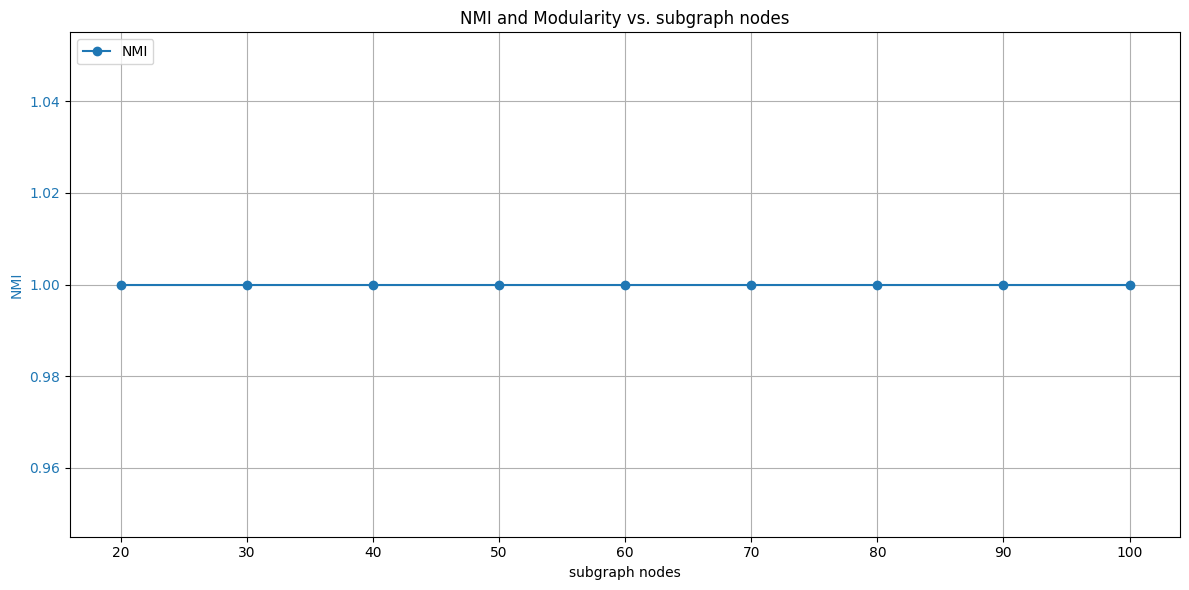

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf  # Import TensorFlow with alias tf
import random

from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from sklearn.cluster import KMeans, kmeans_plusplus  # Import KMeans and kmeans_plusplus
from sklearn.metrics import normalized_mutual_info_score
import networkx as nx

# Define the modularity calculation function
def calculate_modularity(adj_matrix, clusters):
    G = nx.from_numpy_array(adj_matrix)
    m = G.number_of_edges()
    if m == 0:
        return 0

    degrees = np.array([val for (node, val) in G.degree()])
    cluster_dict = {i: [] for i in range(len(clusters))}
    for node, cluster in enumerate(clusters):
        cluster_dict[cluster].append(node)

    modularity = 0
    for community in cluster_dict.values():
        subgraph = G.subgraph(community)
        e_community = subgraph.number_of_edges()
        a_community = sum(degrees[node] for node in community)
        expected_edges = (a_community / (2 * m)) ** 2
        modularity += (e_community / m) - expected_edges

    return modularity

# List of unique `encoding_dim` values
node_values = [20, 30, 40, 50, 60, 70, 80 ,90, 100 ]

# Initialize the list to store trial results
trial_results2 = []

# Assuming you have these functions defined
similarity_matrices = create_similarity_matrices(adj_matrix)
combined_matrix = combine_similarity_matrices(similarity_matrices)

# Variable to store the best result
best_result = None
best_nmi = -1

# Loop over the encoding_dim values
for k in node_values:
    batch_size = 16
    epochs = 400
    n_clusters = 4
    encoding_dim = 120
    num_nodes = combined_matrix.shape[0]
    flattened_matrix = combined_matrix.reshape(num_nodes, -1)
    input_dim = flattened_matrix.shape[1]

    # Autoencoder architecture
    input_layer = Input(shape=(input_dim,))
    encoded = Dense(encoding_dim, activation='relu')(input_layer)
    decoded = Dense(input_dim, activation='sigmoid')(encoded)
    autoencoder = Model(input_layer, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')

    autoencoder.fit(flattened_matrix, flattened_matrix, epochs=epochs, batch_size=batch_size, verbose=0)

    encoder = Model(input_layer, encoded)
    encoded_input = encoder.predict(flattened_matrix)
    #k = 20 # Hyperparameter k
    selected_nodes = select_nodes(graph, k)
    set_selected_nodes = set(selected_nodes)
    subgraph = graph.subgraph(set_selected_nodes)
    #transform the embeding to dict
    embeddings=encoded_input
    embeddings_dict = embeddings_to_dict(embeddings, graph.nodes())
    embedding=extract_subgraph_embedding(graph, subgraph, embeddings_dict)
    num_clusters = 4
    clusters = spectral_clustering_with_embeddings(subgraph, embedding, num_clusters)
    community_structure = CommunityDetection(graph,num_clusters, clusters,embeddings)
    cluster_dict =community_structure
    cluster_list = [cluster_dict[node] for node in sorted(cluster_dict.keys())]
    # Calculate modularity
    modularity = calculate_modularity(adj_matrix, cluster_list)
    nmi = normalized_mutual_info_score(ground, cluster_list)
    print(cluster_list)
    print(nmi , "&",modularity)
    # Save the best result


    # Log results for CSV
    trial_results2.append({
        'subgraph_nodes': k,
        'batch_size': batch_size,
        'epochs': epochs,
        'n_clusters': n_clusters,
        'NMI': nmi,
        'Modularity': modularity
    })

# Save trial results to CSV
df_results2 = pd.DataFrame(trial_results2)
df_results2.to_csv('simple_loop_results.csv', index=False)
print('Results saved to simple_loop_results.csv')

# Plot the results
mean_results2 = df_results2.groupby('subgraph_nodes').mean()

plt.figure(figsize=(12, 6))

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot NMI
color = 'tab:blue'
ax1.set_xlabel('subgraph nodes')
ax1.set_ylabel('NMI', color=color)
ax1.plot(mean_results2.index, mean_results2['NMI'], marker='o', linestyle='-', color=color)
ax1.tick_params(axis='y', labelcolor=color)


plt.title('NMI and Modularity vs. subgraph nodes')
ax1.legend(['NMI'], loc='upper left')
#ax2.legend(['Modularity'], loc='upper right')
ax1.grid(True)
plt.tight_layout()
plt.show()




4/4 [==============================] - 0s 3ms/step


/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


[3, 0, 2, 1, 2, 1, 3, 3, 1, 3, 3, 2, 3, 1, 2, 2, 3, 1, 2, 2, 1, 0, 2, 2, 1, 0, 2, 0, 2, 3, 0, 3, 3, 2, 1, 2, 3, 0, 3, 2, 2, 0, 1, 1, 1, 1, 3, 0, 3, 0, 0, 2, 0, 2, 0, 1, 2, 0, 1, 1, 3, 0, 1, 1, 0, 1, 3, 1, 0, 0, 2, 0, 3, 2, 0, 0, 1, 2, 2, 2, 0, 2, 2, 3, 3, 0, 0, 0, 0, 2, 3, 3, 1, 3, 3, 0, 1, 2, 3, 1, 0, 2, 3, 0, 3, 3, 2, 3, 1, 3, 1, 0, 0, 3, 2, 2, 1, 1, 1, 1, 3, 1, 2, 1, 0, 1, 3, 0]
1.0 & 0.453125
4/4 [==============================] - 0s 6ms/step


/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


[3, 1, 2, 0, 2, 0, 3, 3, 0, 3, 3, 2, 3, 0, 2, 2, 3, 0, 2, 2, 0, 3, 2, 2, 0, 1, 2, 3, 2, 3, 1, 3, 3, 2, 0, 2, 3, 1, 3, 2, 2, 1, 0, 0, 0, 0, 3, 1, 3, 1, 1, 2, 1, 2, 1, 0, 2, 1, 0, 0, 3, 1, 0, 0, 1, 0, 3, 0, 1, 1, 0, 3, 3, 2, 1, 1, 0, 2, 2, 2, 1, 2, 2, 3, 3, 1, 1, 1, 1, 2, 3, 3, 0, 3, 3, 1, 0, 2, 3, 0, 1, 2, 3, 1, 3, 3, 2, 3, 0, 3, 0, 1, 1, 3, 2, 2, 0, 0, 0, 0, 3, 0, 2, 0, 1, 0, 3, 1]
0.9178599925278694 & 0.417724609375
4/4 [==============================] - 0s 5ms/step


...

[1, 2, 3, 0, 3, 0, 1, 1, 0, 1, 1, 3, 1, 0, 3, 3, 1, 0, 3, 3, 0, 2, 3, 3, 0, 2, 3, 2, 3, 1, 2, 1, 1, 3, 0, 3, 1, 2, 1, 3, 3, 2, 0, 0, 0, 0, 1, 2, 1, 2, 2, 3, 2, 3, 2, 0, 3, 2, 0, 0, 1, 2, 0, 0, 2, 0, 1, 0, 2, 2, 3, 2, 1, 3, 2, 2, 0, 3, 3, 3, 2, 3, 3, 1, 1, 2, 2, 2, 2, 3, 1, 1, 0, 1, 1, 2, 0, 3, 1, 0, 2, 3, 1, 2, 1, 1, 3, 1, 0, 1, 0, 2, 2, 1, 3, 3, 0, 0, 0, 0, 1, 0, 3, 0, 2, 0, 1, 2]
1.0 & 0.453125
4/4 [==============================] - 0s 3ms/step


/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


[0, 2, 1, 3, 1, 3, 0, 0, 3, 0, 0, 1, 0, 3, 1, 1, 0, 3, 1, 1, 3, 2, 1, 1, 3, 2, 1, 2, 1, 0, 2, 0, 0, 1, 3, 1, 0, 2, 0, 1, 1, 2, 3, 3, 3, 3, 0, 2, 0, 2, 2, 1, 2, 1, 2, 3, 1, 2, 3, 3, 0, 2, 3, 3, 2, 3, 0, 3, 2, 2, 1, 2, 0, 1, 2, 2, 3, 1, 1, 1, 2, 1, 1, 0, 0, 2, 2, 2, 2, 1, 0, 0, 3, 0, 0, 2, 3, 1, 0, 3, 2, 1, 0, 2, 0, 0, 1, 0, 3, 0, 3, 2, 2, 0, 1, 1, 3, 3, 3, 3, 0, 3, 1, 3, 2, 3, 0, 2]
1.0 & 0.453125
4/4 [==============================] - 0s 3ms/step
[1, 3, 0, 2, 0, 2, 1, 1, 2, 1, 1, 0, 1, 2, 0, 0, 1, 2, 0, 0, 2, 3, 0, 0, 2, 3, 0, 3, 0, 1, 3, 1, 1, 0, 2, 0, 1, 3, 1, 0, 0, 3, 2, 2, 2, 2, 1, 3, 1, 3, 3, 0, 3, 0, 3, 2, 0, 3, 2, 2, 1, 3, 2, 2, 3, 2, 1, 2, 3, 3, 0, 3, 1, 0, 3, 3, 2, 0, 0, 0, 3, 0, 0, 1, 1, 3, 3, 3, 3, 0, 1, 1, 2, 1, 1, 3, 2, 0, 1, 2, 3, 0, 1, 3, 1, 1, 0, 1, 2, 1, 2, 0, 3, 1, 0, 0, 2, 2, 2, 2, 1, 2, 0, 2, 3, 2, 1, 3]
0.9748319234674033 & 0.4412841796875
Results saved to simple_loop_results.csv


/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


<Figure size 1200x600 with 0 Axes>

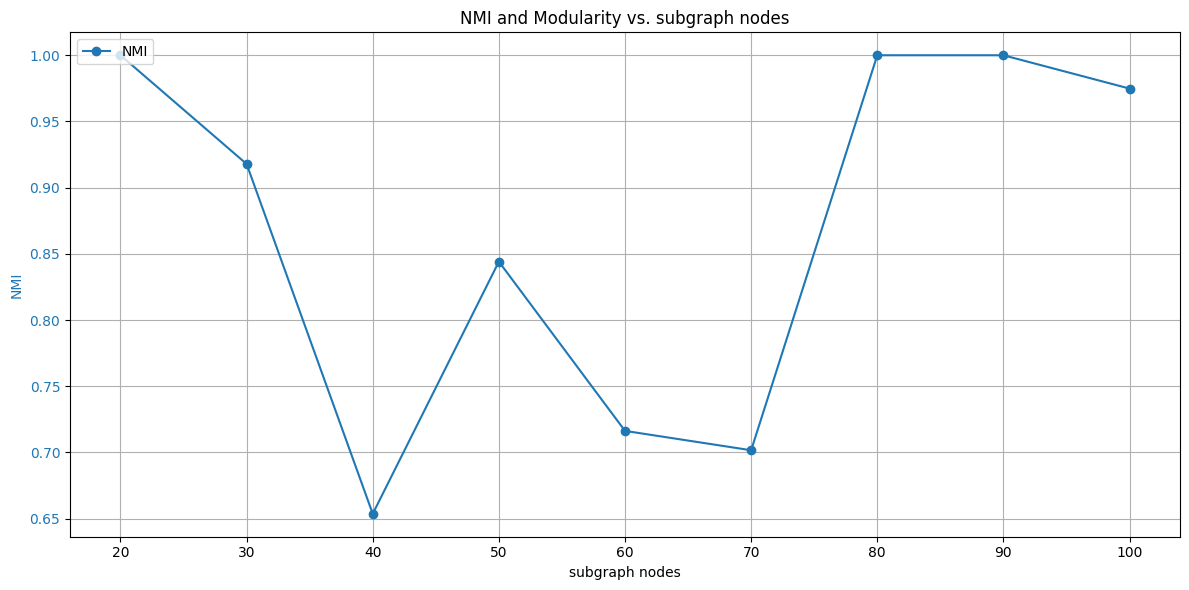

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf  # Import TensorFlow with alias tf
import random

from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from sklearn.cluster import KMeans, kmeans_plusplus  # Import KMeans and kmeans_plusplus
from sklearn.metrics import normalized_mutual_info_score
import networkx as nx

# Define the modularity calculation function
def calculate_modularity(adj_matrix, clusters):
    G = nx.from_numpy_array(adj_matrix)
    m = G.number_of_edges()
    if m == 0:
        return 0

    degrees = np.array([val for (node, val) in G.degree()])
    cluster_dict = {i: [] for i in range(len(clusters))}
    for node, cluster in enumerate(clusters):
        cluster_dict[cluster].append(node)

    modularity = 0
    for community in cluster_dict.values():
        subgraph = G.subgraph(community)
        e_community = subgraph.number_of_edges()
        a_community = sum(degrees[node] for node in community)
        expected_edges = (a_community / (2 * m)) ** 2
        modularity += (e_community / m) - expected_edges

    return modularity

# List of unique `encoding_dim` values
node_values = [20, 30, 40, 50, 60, 70, 80 ,90, 100 ]

# Initialize the list to store trial results

trial_results3 = []

# Assuming you have these functions defined
similarity_matrices = create_similarity_matrices(adj_matrix)
combined_matrix = combine_similarity_matrices(similarity_matrices)

# Variable to store the best result
best_result = None
best_nmi = -1

# Loop over the encoding_dim values
for k in node_values:
    batch_size = 16
    epochs = 400
    n_clusters = 4
    encoding_dim = 120
    num_nodes = combined_matrix.shape[0]
    flattened_matrix = combined_matrix.reshape(num_nodes, -1)
    input_dim = flattened_matrix.shape[1]

    # Autoencoder architecture
    input_layer = Input(shape=(input_dim,))
    encoded = Dense(encoding_dim, activation='relu')(input_layer)
    decoded = Dense(input_dim, activation='sigmoid')(encoded)
    autoencoder = Model(input_layer, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')

    autoencoder.fit(flattened_matrix, flattened_matrix, epochs=epochs, batch_size=batch_size, verbose=0)

    encoder = Model(input_layer, encoded)
    encoded_input = encoder.predict(flattened_matrix)
    #k = 20 # Hyperparameter k
    selected_nodes = select_nodes(graph, k)
    set_selected_nodes = set(selected_nodes)
    subgraph = graph.subgraph(set_selected_nodes)
    #transform the embeding to dict
    embeddings=encoded_input
    embeddings_dict = embeddings_to_dict(embeddings, graph.nodes())
    embedding=extract_subgraph_embedding(graph, subgraph, embeddings_dict)
    num_clusters = 4
    clusters = spectral_clustering_with_embeddings(subgraph, embedding, num_clusters)
    community_structure = CommunityDetection(graph,num_clusters, clusters,embeddings)
    cluster_dict =community_structure
    cluster_list = [cluster_dict[node] for node in sorted(cluster_dict.keys())]
    # Calculate modularity
    modularity = calculate_modularity(adj_matrix, cluster_list)
    nmi = normalized_mutual_info_score(ground, cluster_list)
    print(cluster_list)
    print(nmi , "&",modularity)
    # Save the best result


    # Log results for CSV
    trial_results3.append({
        'subgraph_nodes': k,
        'batch_size': batch_size,
        'epochs': epochs,
        'n_clusters': n_clusters,
        'NMI': nmi,
        'Modularity': modularity
    })

# Save trial results to CSV
df_results3 = pd.DataFrame(trial_results3)
df_results3.to_csv('simple_loop_results.csv', index=False)
print('Results saved to simple_loop_results.csv')

# Plot the results
mean_results3 = df_results3.groupby('subgraph_nodes').mean()

plt.figure(figsize=(12, 6))

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot NMI
color = 'tab:blue'
ax1.set_xlabel('subgraph nodes')
ax1.set_ylabel('NMI', color=color)
ax1.plot(mean_results3.index, mean_results3['NMI'], marker='o', linestyle='-', color=color)
ax1.tick_params(axis='y', labelcolor=color)


plt.title('NMI and Modularity vs. subgraph nodes')
ax1.legend(['NMI'], loc='upper left')
#ax2.legend(['Modularity'], loc='upper right')
ax1.grid(True)
plt.tight_layout()
plt.show()




4/4 [==============================] - 0s 3ms/step


/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


[3, 2, 2, 2, 0, 1, 1, 3, 0, 2, 1, 2, 2, 1, 1, 0, 2, 0, 1, 2, 0, 0, 0, 3, 0, 2, 0, 1, 1, 3, 1, 0, 0, 0, 0, 3, 0, 0, 1, 0, 3, 0, 0, 0, 2, 1, 3, 3, 3, 1, 1, 3, 2, 2, 3, 1, 0, 0, 2, 2, 0, 1, 0, 2, 3, 2, 1, 0, 1, 2, 3, 1, 3, 2, 2, 0, 3, 1, 1, 1, 1, 0, 0, 1, 3, 3, 1, 1, 2, 2, 0, 0, 2, 1, 2, 2, 0, 0, 3, 0, 2, 0, 0, 0, 0, 2, 0, 2, 0, 3, 0, 0, 1, 0, 1, 1, 2, 0, 3, 1, 3, 0, 1, 3, 0, 1, 0, 3]
0.32839488105153564 & 0.0921630859375
4/4 [==============================] - 0s 3ms/step


/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


[0, 3, 3, 2, 2, 2, 0, 0, 1, 3, 0, 1, 1, 0, 0, 2, 0, 3, 0, 2, 1, 2, 1, 1, 0, 3, 2, 0, 0, 0, 0, 2, 1, 0, 0, 0, 1, 1, 0, 0, 0, 3, 0, 0, 2, 3, 0, 1, 2, 3, 0, 0, 3, 3, 0, 0, 0, 2, 3, 2, 0, 2, 2, 3, 1, 1, 0, 0, 2, 3, 0, 3, 2, 3, 3, 3, 2, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 2, 3, 0, 2, 3, 1, 2, 3, 1, 2, 0, 2, 1, 1, 2, 0, 0, 1, 2, 3, 2, 0, 3, 3, 0, 3, 0, 3, 1, 2, 0, 0, 1, 2, 0, 0, 3, 0, 3, 3]
0.27675488278212873 & 0.086669921875
4/4 [==============================] - 0s 3ms/step


...

[3, 1, 1, 1, 0, 3, 2, 3, 0, 1, 2, 3, 1, 1, 3, 0, 1, 1, 2, 3, 0, 0, 0, 1, 2, 1, 1, 2, 2, 2, 2, 1, 0, 2, 0, 0, 0, 0, 1, 2, 0, 1, 0, 2, 1, 1, 3, 3, 3, 1, 2, 3, 1, 1, 3, 2, 0, 0, 1, 1, 3, 3, 2, 1, 3, 0, 3, 0, 0, 1, 3, 2, 1, 1, 1, 2, 1, 2, 2, 1, 3, 0, 2, 2, 3, 3, 2, 2, 1, 0, 0, 2, 1, 1, 1, 1, 0, 2, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 3, 1, 1, 2, 3, 3, 2, 0, 1, 3, 2, 0, 0, 2, 3, 0, 2, 1, 1]
0.6213525464733498 & 0.2296142578125
4/4 [==============================] - 0s 3ms/step


/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


[3, 1, 1, 1, 2, 3, 0, 3, 2, 1, 0, 1, 2, 1, 0, 2, 1, 1, 0, 3, 2, 2, 2, 2, 0, 1, 1, 0, 0, 2, 0, 1, 2, 2, 2, 2, 2, 2, 1, 0, 2, 1, 2, 0, 3, 1, 3, 2, 3, 1, 0, 3, 1, 1, 3, 0, 3, 2, 1, 3, 0, 3, 0, 1, 2, 2, 3, 2, 2, 1, 3, 0, 3, 1, 1, 0, 3, 0, 0, 1, 0, 0, 0, 0, 3, 3, 0, 0, 1, 3, 2, 0, 1, 2, 1, 1, 2, 0, 2, 1, 2, 2, 2, 0, 2, 2, 2, 0, 2, 3, 0, 1, 0, 3, 0, 0, 2, 1, 3, 0, 2, 2, 0, 3, 2, 0, 1, 3]
0.6870194450710778 & 0.2510986328125
4/4 [==============================] - 0s 3ms/step
[0, 2, 2, 2, 1, 0, 3, 0, 1, 2, 3, 0, 1, 2, 0, 1, 2, 2, 3, 0, 1, 1, 1, 1, 3, 2, 2, 3, 3, 3, 3, 2, 1, 0, 1, 1, 1, 1, 3, 3, 1, 2, 1, 3, 2, 2, 0, 0, 0, 2, 3, 0, 2, 2, 0, 3, 0, 1, 2, 2, 0, 0, 3, 2, 0, 1, 0, 1, 1, 2, 0, 3, 2, 2, 2, 3, 2, 3, 3, 2, 0, 0, 3, 3, 0, 0, 3, 3, 2, 0, 1, 3, 2, 2, 2, 2, 1, 3, 1, 2, 1, 1, 1, 3, 1, 1, 1, 0, 3, 0, 3, 2, 3, 0, 0, 3, 1, 2, 0, 3, 1, 1, 3, 0, 3, 3, 2, 0]
0.7610160842954731 & 0.2747802734375
Results saved to simple_loop_results.csv


/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


<Figure size 1200x600 with 0 Axes>

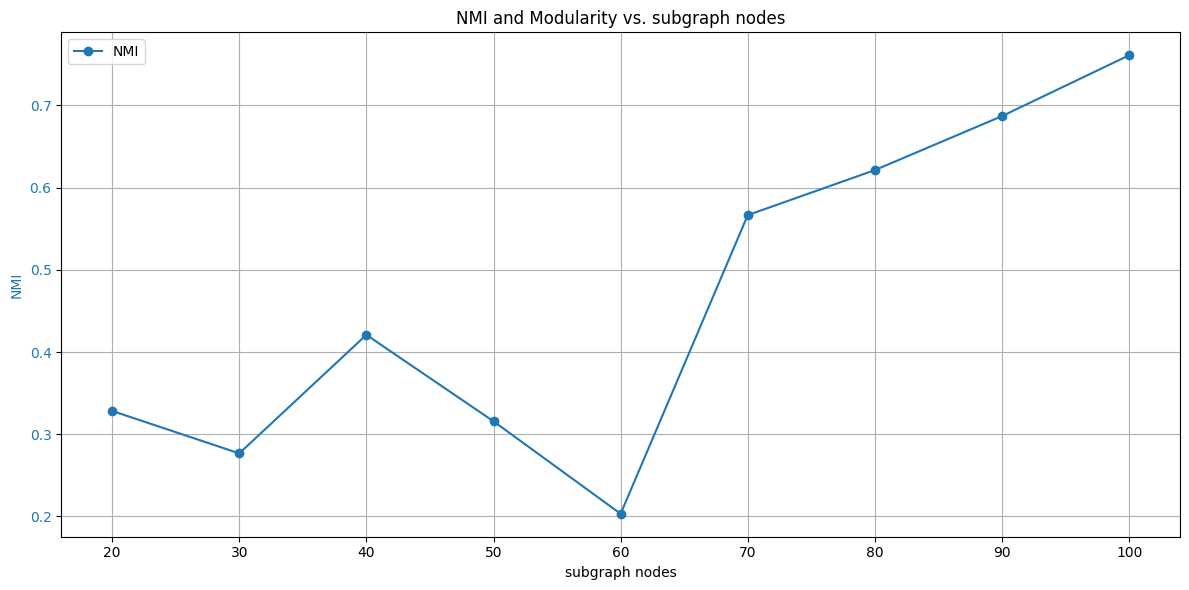

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf  # Import TensorFlow with alias tf
import random

from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from sklearn.cluster import KMeans, kmeans_plusplus  # Import KMeans and kmeans_plusplus
from sklearn.metrics import normalized_mutual_info_score
import networkx as nx

# Define the modularity calculation function
def calculate_modularity(adj_matrix, clusters):
    G = nx.from_numpy_array(adj_matrix)
    m = G.number_of_edges()
    if m == 0:
        return 0

    degrees = np.array([val for (node, val) in G.degree()])
    cluster_dict = {i: [] for i in range(len(clusters))}
    for node, cluster in enumerate(clusters):
        cluster_dict[cluster].append(node)

    modularity = 0
    for community in cluster_dict.values():
        subgraph = G.subgraph(community)
        e_community = subgraph.number_of_edges()
        a_community = sum(degrees[node] for node in community)
        expected_edges = (a_community / (2 * m)) ** 2
        modularity += (e_community / m) - expected_edges

    return modularity

# List of unique `encoding_dim` values
node_values = [20, 30, 40, 50, 60, 70, 80 ,90, 100 ]

# Initialize the list to store trial results
trial_results4 = []

# Assuming you have these functions defined
similarity_matrices = create_similarity_matrices(adj_matrix)
combined_matrix = combine_similarity_matrices(similarity_matrices)

# Variable to store the best result
best_result = None
best_nmi = -1

# Loop over the encoding_dim values
for k in node_values:
    batch_size = 16
    epochs = 400
    n_clusters = 4
    encoding_dim = 60
    num_nodes = combined_matrix.shape[0]
    flattened_matrix = combined_matrix.reshape(num_nodes, -1)
    input_dim = flattened_matrix.shape[1]

    # Autoencoder architecture
    input_layer = Input(shape=(input_dim,))
    encoded = Dense(encoding_dim, activation='relu')(input_layer)
    decoded = Dense(input_dim, activation='sigmoid')(encoded)
    autoencoder = Model(input_layer, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')

    autoencoder.fit(flattened_matrix, flattened_matrix, epochs=epochs, batch_size=batch_size, verbose=0)

    encoder = Model(input_layer, encoded)
    encoded_input = encoder.predict(flattened_matrix)
    #k = 20 # Hyperparameter k
    selected_nodes = select_nodes(graph, k)
    set_selected_nodes = set(selected_nodes)
    subgraph = graph.subgraph(set_selected_nodes)
    #transform the embeding to dict
    embeddings=encoded_input
    embeddings_dict = embeddings_to_dict(embeddings, graph.nodes())
    embedding=extract_subgraph_embedding(graph, subgraph, embeddings_dict)
    num_clusters = 4
    clusters = spectral_clustering_with_embeddings(subgraph, embedding, num_clusters)
    community_structure = CommunityDetection(graph,num_clusters, clusters,embeddings)
    cluster_dict =community_structure
    cluster_list = [cluster_dict[node] for node in sorted(cluster_dict.keys())]
    # Calculate modularity
    modularity = calculate_modularity(adj_matrix, cluster_list)
    nmi = normalized_mutual_info_score(ground, cluster_list)
    print(cluster_list)
    print(nmi , "&",modularity)
    # Save the best result


    # Log results for CSV
    trial_results4.append({
        'subgraph_nodes': k,
        'batch_size': batch_size,
        'epochs': epochs,
        'n_clusters': n_clusters,
        'NMI': nmi,
        'Modularity': modularity
    })

# Save trial results to CSV
df_results4 = pd.DataFrame(trial_results4)
df_results4.to_csv('simple_loop_results.csv', index=False)
print('Results saved to simple_loop_results.csv')

# Plot the results
mean_results4 = df_results4.groupby('subgraph_nodes').mean()

plt.figure(figsize=(12, 6))

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot NMI
color = 'tab:blue'
ax1.set_xlabel('subgraph nodes')
ax1.set_ylabel('NMI', color=color)
ax1.plot(mean_results4.index, mean_results4['NMI'], marker='o', linestyle='-', color=color)
ax1.tick_params(axis='y', labelcolor=color)


plt.title('NMI and Modularity vs. subgraph nodes')
ax1.legend(['NMI'], loc='upper left')
#ax2.legend(['Modularity'], loc='upper right')
ax1.grid(True)
plt.tight_layout()
plt.show()




4/4 [==============================] - 0s 3ms/step


/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


[0, 3, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 2, 3, 3, 2, 0, 0, 0, 1, 3, 0, 2, 1, 3, 3, 3, 1, 3, 3, 3, 0, 3, 3, 1, 1, 0, 0, 0, 3, 3, 0, 1, 3, 0, 1, 0, 1, 0, 3, 3, 2, 3, 2, 2, 1, 3, 0, 2, 1, 2, 0, 0, 0, 1, 2, 3, 1, 0, 1, 3, 2, 0, 0, 3, 3, 1, 3, 0, 1, 0, 3, 2, 0, 3, 1, 3, 0, 0, 3, 0, 0, 0, 1, 3, 1, 3, 1, 3, 0, 3, 1, 1, 0, 3, 0, 0, 3, 2, 0]
0.5118028538470567 & 0.4045384265333223
4/4 [==============================] - 0s 3ms/step


/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


[2, 1, 3, 0, 2, 0, 3, 2, 2, 2, 0, 0, 1, 3, 0, 3, 2, 0, 1, 1, 0, 2, 2, 2, 0, 1, 1, 0, 0, 1, 1, 1, 3, 1, 1, 1, 0, 1, 1, 0, 0, 2, 0, 1, 1, 1, 0, 3, 1, 0, 0, 2, 0, 0, 1, 1, 0, 1, 0, 0, 3, 1, 0, 0, 3, 0, 1, 0, 2, 0, 0, 1, 0, 0, 0, 1, 0, 2, 2, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 2, 1, 0, 0, 0, 0, 1, 3, 1, 0, 1, 2, 1, 3, 0, 2, 1, 0, 2, 1, 0, 0]
0.5803077033890106 & 0.4109213373109543
4/4 [==============================] - 0s 3ms/step


...

/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


[1, 0, 2, 3, 1, 3, 2, 2, 2, 1, 3, 1, 0, 2, 0, 2, 1, 1, 0, 0, 1, 2, 2, 1, 1, 0, 0, 1, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 2, 3, 1, 0, 0, 0, 0, 1, 2, 1, 1, 1, 2, 3, 1, 0, 0, 1, 0, 0, 0, 2, 0, 1, 1, 2, 1, 1, 1, 2, 1, 1, 0, 3, 1, 3, 1, 1, 2, 2, 0, 0, 3, 0, 1, 3, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 3, 3, 0, 2, 0, 3, 0, 1, 0, 2, 3, 2, 0, 1, 2, 1, 1, 1]
0.589558563740315 & 0.4619620032519979
4/4 [==============================] - 0s 5ms/step


/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


[3, 0, 2, 1, 3, 1, 2, 3, 3, 3, 1, 1, 0, 2, 0, 2, 3, 0, 0, 0, 0, 3, 3, 3, 3, 0, 0, 0, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 2, 1, 3, 0, 0, 0, 0, 1, 2, 0, 1, 3, 3, 1, 1, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 2, 0, 0, 1, 3, 3, 0, 0, 1, 1, 1, 0, 0, 3, 3, 0, 3, 1, 0, 1, 1, 0, 0, 0, 1, 0, 3, 0, 0, 3, 0, 0, 0, 0, 1, 0, 2, 0, 1, 0, 3, 0, 2, 1, 3, 0, 1, 3, 0, 0, 1]
0.5842137749273181 & 0.47876088767301184
4/4 [==============================] - 0s 3ms/step
[3, 1, 0, 0, 3, 0, 0, 3, 3, 3, 0, 2, 1, 0, 1, 0, 3, 2, 1, 1, 2, 3, 3, 3, 2, 1, 1, 2, 2, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 3, 1, 1, 2, 1, 0, 0, 2, 0, 2, 3, 0, 0, 1, 1, 2, 2, 0, 2, 0, 1, 2, 2, 0, 2, 2, 0, 3, 2, 2, 1, 0, 0, 0, 2, 2, 3, 3, 1, 1, 0, 3, 0, 0, 1, 2, 2, 0, 1, 3, 2, 2, 3, 1, 2, 2, 2, 0, 1, 0, 1, 0, 1, 3, 1, 0, 0, 3, 1, 0, 3, 2, 2, 0]
0.6705267053668703 & 0.5359037067985917
4/4 [==============================] - 0s 3ms/step
[3, 0, 1, 2, 3, 2, 1, 3, 3, 3, 2, 2, 1, 1, 1, 1, 3, 0, 1, 0, 0, 3, 3, 3, 0, 0, 1, 0, 3, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 2, 3

<Figure size 1200x600 with 0 Axes>

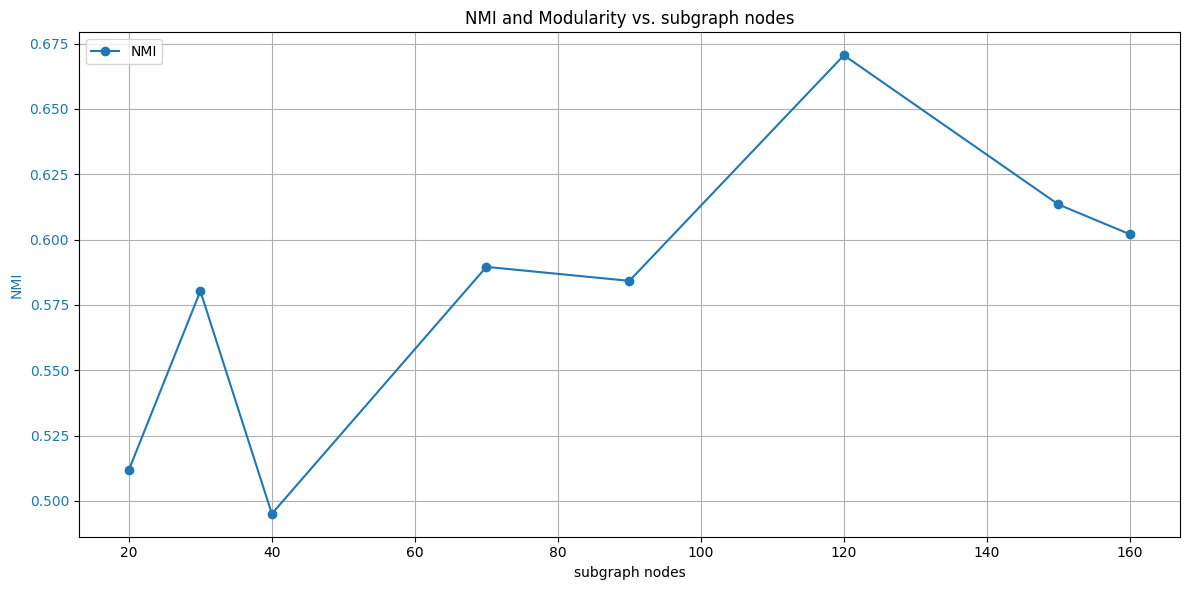

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf  # Import TensorFlow with alias tf
import random

from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from sklearn.cluster import KMeans, kmeans_plusplus  # Import KMeans and kmeans_plusplus
from sklearn.metrics import normalized_mutual_info_score
import networkx as nx

# Define the modularity calculation function
def calculate_modularity(adj_matrix, clusters):
    G = nx.from_numpy_array(adj_matrix)
    m = G.number_of_edges()
    if m == 0:
        return 0

    degrees = np.array([val for (node, val) in G.degree()])
    cluster_dict = {i: [] for i in range(len(clusters))}
    for node, cluster in enumerate(clusters):
        cluster_dict[cluster].append(node)

    modularity = 0
    for community in cluster_dict.values():
        subgraph = G.subgraph(community)
        e_community = subgraph.number_of_edges()
        a_community = sum(degrees[node] for node in community)
        expected_edges = (a_community / (2 * m)) ** 2
        modularity += (e_community / m) - expected_edges

    return modularity

# List of unique `encoding_dim` values
node_values = [20, 30, 40, 70 ,90, 120 ,150,160]

# Initialize the list to store trial results
trial_results5 = []

# Assuming you have these functions defined
similarity_matrices = create_similarity_matrices(adj_matrix)
combined_matrix = combine_similarity_matrices(similarity_matrices)

# Variable to store the best result
best_result = None
best_nmi = -1

# Loop over the encoding_dim values
for k in node_values:
    batch_size = 16
    epochs = 400
    n_clusters = 12
    encoding_dim = 90
    num_nodes = combined_matrix.shape[0]
    flattened_matrix = combined_matrix.reshape(num_nodes, -1)
    input_dim = flattened_matrix.shape[1]

    # Autoencoder architecture
    input_layer = Input(shape=(input_dim,))
    encoded = Dense(encoding_dim, activation='relu')(input_layer)
    decoded = Dense(input_dim, activation='sigmoid')(encoded)
    autoencoder = Model(input_layer, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')

    autoencoder.fit(flattened_matrix, flattened_matrix, epochs=epochs, batch_size=batch_size, verbose=0)

    encoder = Model(input_layer, encoded)
    encoded_input = encoder.predict(flattened_matrix)
    #k = 20 # Hyperparameter k
    selected_nodes = select_nodes(graph, k)
    set_selected_nodes = set(selected_nodes)
    subgraph = graph.subgraph(set_selected_nodes)
    #transform the embeding to dict
    embeddings=encoded_input
    embeddings_dict = embeddings_to_dict(embeddings, graph.nodes())
    embedding=extract_subgraph_embedding(graph, subgraph, embeddings_dict)
    num_clusters = 4
    clusters = spectral_clustering_with_embeddings(subgraph, embedding, num_clusters)
    community_structure = CommunityDetection(graph,num_clusters, clusters,embeddings)
    cluster_dict =community_structure
    cluster_list = [cluster_dict[node] for node in sorted(cluster_dict.keys())]
    # Calculate modularity
    modularity = calculate_modularity(adj_matrix, cluster_list)
    nmi = normalized_mutual_info_score(ground, cluster_list)
    print(cluster_list)
    print(nmi , "&",modularity)
    # Save the best result


    # Log results for CSV
    trial_results5.append({
        'subgraph_nodes': k,
        'batch_size': batch_size,
        'epochs': epochs,
        'n_clusters': n_clusters,
        'NMI': nmi,
        'Modularity': modularity
    })

# Save trial results to CSV
df_results5 = pd.DataFrame(trial_results5)
df_results5.to_csv('simple_loop_results.csv', index=False)
print('Results saved to simple_loop_results.csv')

# Plot the results
mean_results5 = df_results5.groupby('subgraph_nodes').mean()

plt.figure(figsize=(12, 6))

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot NMI
color = 'tab:blue'
ax1.set_xlabel('subgraph nodes')
ax1.set_ylabel('NMI', color=color)
ax1.plot(mean_results5.index, mean_results5['NMI'], marker='o', linestyle='-', color=color)
ax1.tick_params(axis='y', labelcolor=color)


plt.title('NMI and Modularity vs. subgraph nodes')
ax1.legend(['NMI'], loc='upper left')
#ax2.legend(['Modularity'], loc='upper right')
ax1.grid(True)
plt.tight_layout()
plt.show()




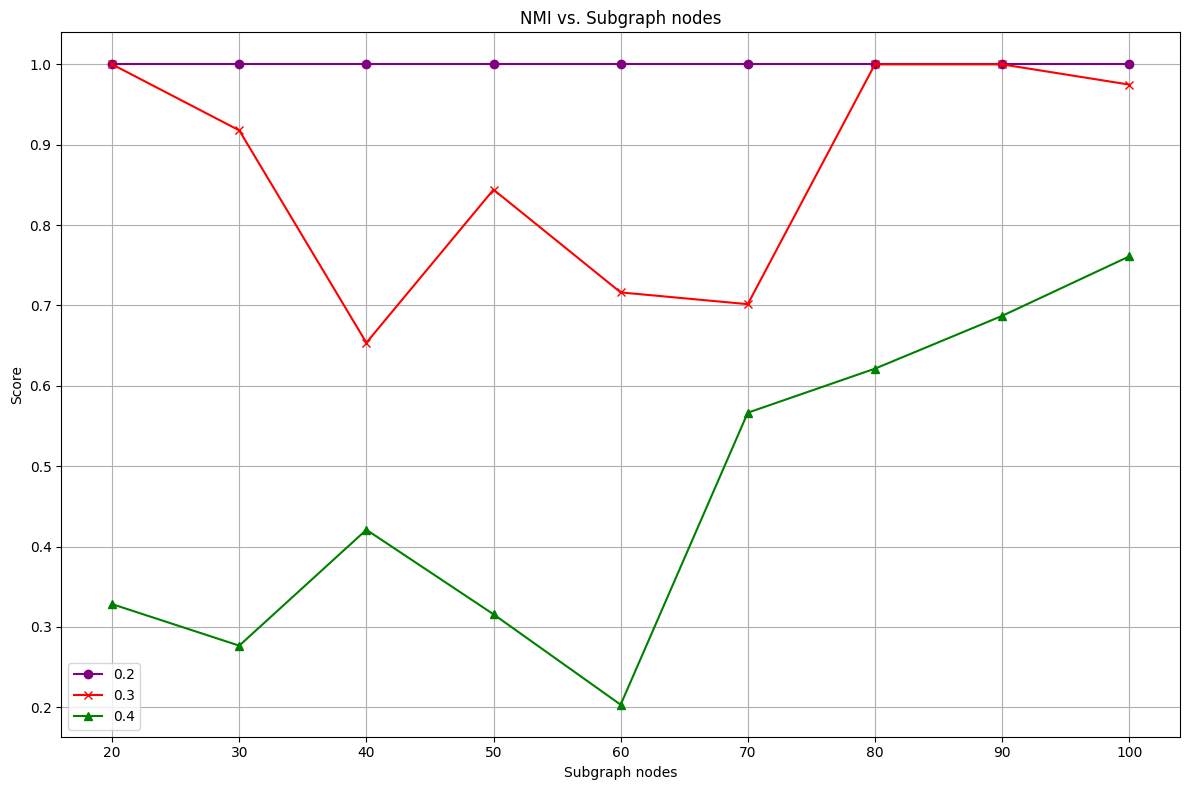

In [ ]:
# Plot the results
mean_results2 = df_results2.groupby('subgraph_nodes').mean()
mean_results3 = df_results3.groupby('subgraph_nodes').mean()
mean_results4 = df_results4.groupby('subgraph_nodes').mean()
# Increase the height of the plot by changing the figsize
plt.figure(figsize=(12, 8))

# Plot NMI and Modularity on the same y-axis
plt.plot(mean_results2.index, mean_results2['NMI'], marker='o', linestyle='-', color='purple', label='0.2')
plt.plot(mean_results3.index, mean_results3['NMI'], marker='x',linestyle='-', color='red', label='0.3')
plt.plot(mean_results4.index, mean_results4['NMI'], marker='^',linestyle='-', color='green', label='0.4')
plt.xlabel('Subgraph nodes')
plt.ylabel('Score')
plt.title('NMI vs. Subgraph nodes')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()


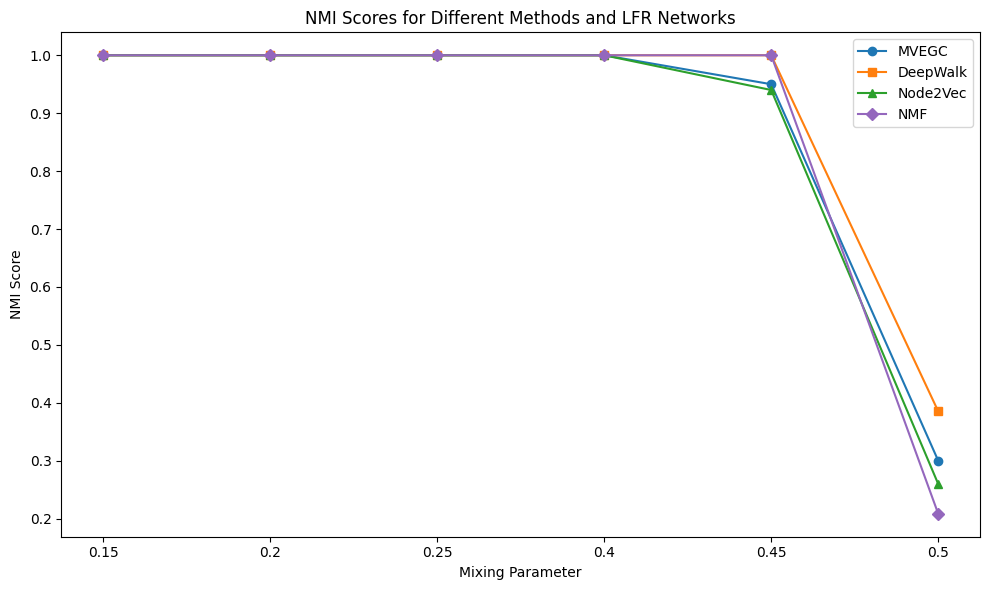

In [ ]:
# Data
lfr_params = [0.15, 0.2, 0.25, 0.4, 0.45, 0.5]
nmi_scores = {
    "MVEGC": [1.0, 1.0, 1.0, 1.0, 0.95, 0.3],
    "DeepWalk": [1.0, 1.0, 1.0, 1.0, 1.0, 0.3852625731134845],
    "Node2Vec": [1.0, 1.0, 1.0, 1.0, 0.94, 0.2597790491323889],
    "NMF": [1.0, 1.0, 1.0, 1.0, 1.0, 0.20838196689425684]
}

# Create the plot
plt.figure(figsize=(10, 6))
x = np.arange(len(lfr_params))
plt.plot(x, nmi_scores["MVEGC"], marker='o', linestyle='-', label='MVEGC', color='#1f77b4')
plt.plot(x, nmi_scores["DeepWalk"], marker='s', linestyle='-', label='DeepWalk', color='#ff7f0e')
plt.plot(x, nmi_scores["Node2Vec"], marker='^', linestyle='-', label='Node2Vec', color='#2ca02c')
plt.plot(x, nmi_scores["NMF"], marker='D', linestyle='-', label='NMF', color='#9467bd')

# Setting the details
plt.xticks(x, [str(param) for param in lfr_params])
plt.xlabel('Mixing Parameter')
plt.ylabel('NMI Score')
plt.title('NMI Scores for Different Methods and LFR Networks')
plt.legend()
plt.tight_layout()
plt.show()

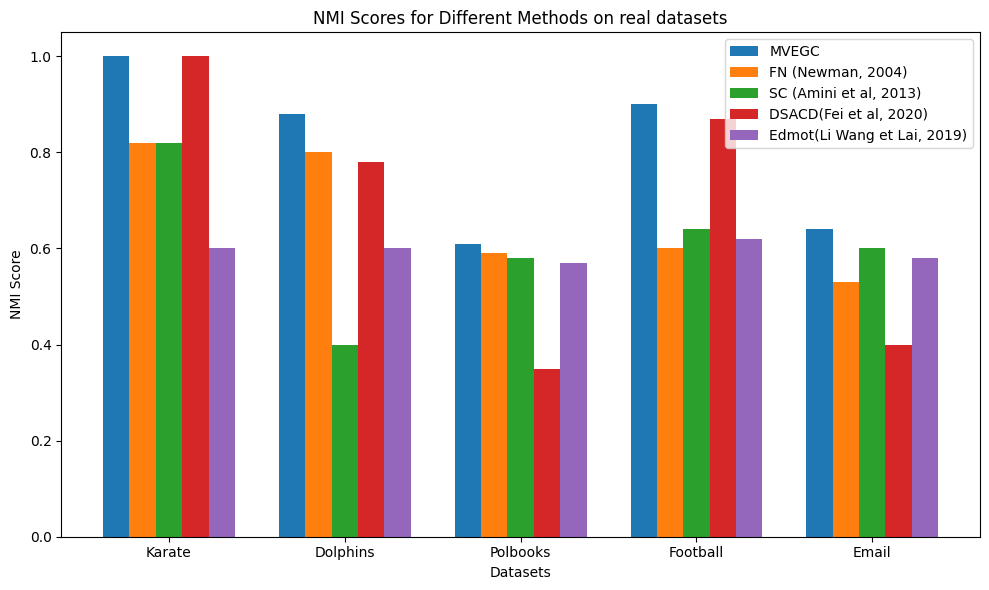

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
lfr_params = ["Karate", "Dolphins", "Polbooks", "Football","Email"]
nmi_scores = {
    "MVEGC": [1.0, 0.88, 0.61, 0.9, 0.64],
    "FN (Newman, 2004)": [0.82, 0.80, 0.59, 0.6, 0.53],
    "SC (Amini et al, 2013)": [0.82, 0.4, 0.58, 0.64, 0.6],
    "DSACD(Fei et al, 2020)": [1.0, 0.78, 0.35, 0.87,0.4 ],
    "Edmot(Li Wang et Lai, 2019)": [0.6, 0.6, 0.57, 0.62,0.58 ]
}

# Create the bar plot
bar_width = 0.15
x = np.arange(len(lfr_params))

fig, ax = plt.subplots(figsize=(10, 6))

# Plot bars
for idx, (method, scores) in enumerate(nmi_scores.items()):
    ax.bar(x + idx * bar_width, scores, bar_width, label=method)

# Setting the details
ax.set_xticks(x + bar_width * (len(nmi_scores) - 1) / 2)
ax.set_xticklabels([str(param) for param in lfr_params])
ax.set_xlabel('Datasets')
ax.set_ylabel('NMI Score')
ax.set_title('NMI Scores for Different Methods on real datasets')
ax.legend()
plt.tight_layout()
plt.show()
